In [202]:
import numpy as np
from scipy.signal import correlate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [180]:
# Parámetros
N = 256
tiempo = np.arange(N)

# f1: pulso
f1 = np.zeros(N)
f1[100:200] = 1

# f2: exponencial decreciente
f2 = 1 * np.exp(-0.03 * tiempo)

# Convolución

La convolución entre dos series temporales es un proceso que consiste en "deslizar" una sobre la otra, multiplicando y sumando sus valores en cada paso, para generar una nueva serie que refleja cómo una señal se ve influida o filtrada por la otra. Intuitivamente, es como aplicar un patrón o “lente” móvil a una señal para resaltar ciertas características, como dar más peso a datos recientes o detectar similitudes a lo largo del tiempo.

## Convolución en DT

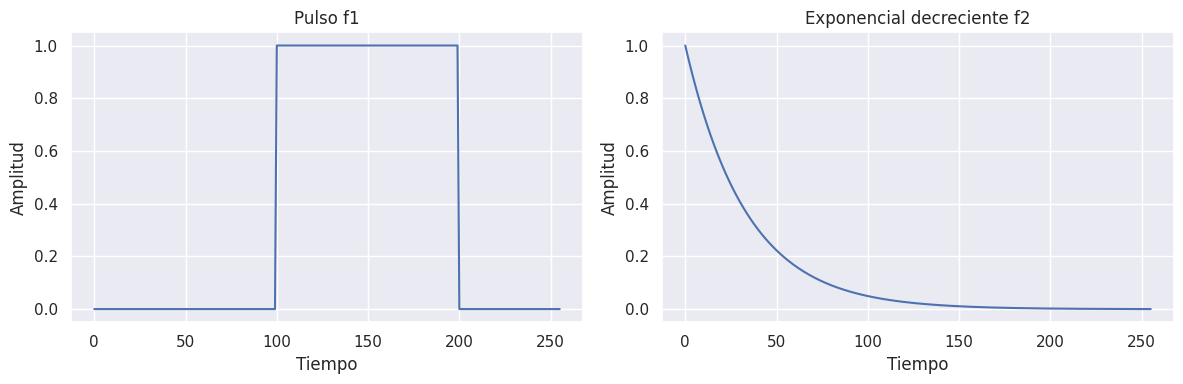

In [181]:
# Gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de f1
sns.lineplot(x=tiempo, y=f1, ax=axes[0])
axes[0].set_title("Pulso f1")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Amplitud")

# Gráfico de f2
sns.lineplot(x=tiempo, y=f2, ax=axes[1])
axes[1].set_title("Exponencial decreciente f2")
axes[1].set_xlabel("Tiempo")
axes[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

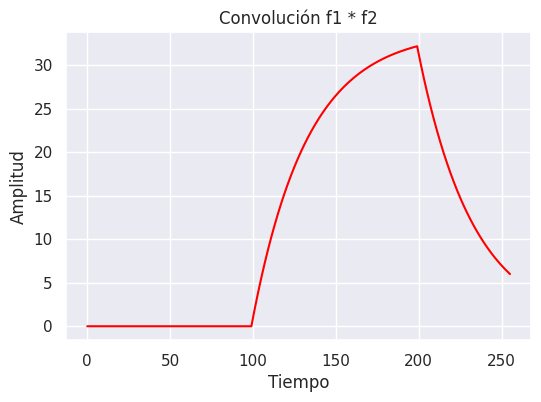

In [182]:
f3 = np.convolve(f1, f2, mode="full")[:N]

plt.figure(figsize=(6, 4))
sns.lineplot(x=tiempo, y=f3, color="red")
plt.title("Convolución f1 * f2")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.show()

## Convolución en DF

In [183]:
# FFT de f1 y f2
fft_f1 = np.fft.fft(f1)
fft_f2 = np.fft.fft(f2)

# Magnitudes
mod_f1 = np.abs(fft_f1)
mod_f2 = np.abs(fft_f2)

Text(0.5, 1.0, 'Magnitudes f2')

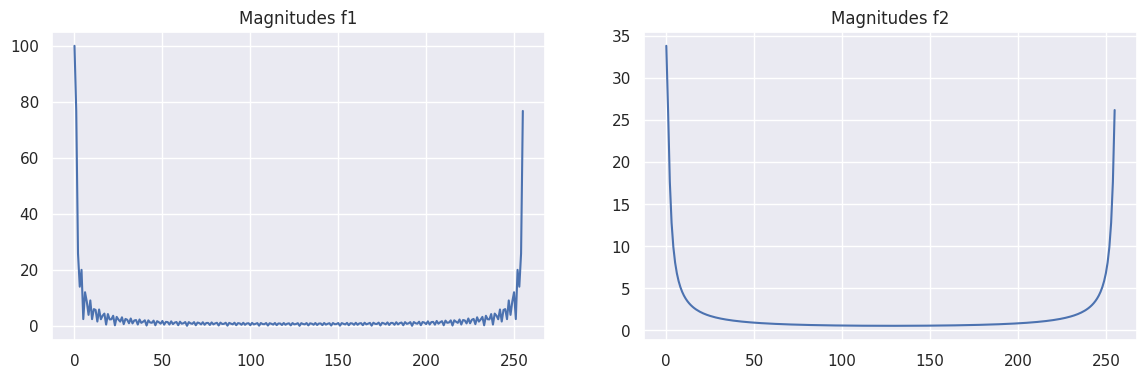

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# FFT magnitudes
sns.lineplot(mod_f1, ax=axes[0])
axes[0].set_title("Magnitudes f1")

sns.lineplot(mod_f2, ax=axes[1])
axes[1].set_title("Magnitudes f2")

Text(0.5, 1.0, 'Mod(FFT f1 * f2)')

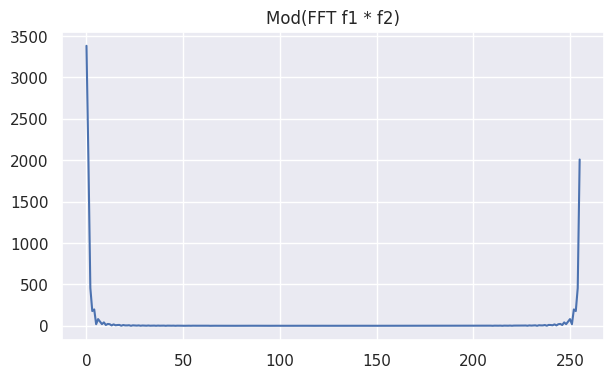

In [185]:
# Producto punto a punto en el dominio de la frecuencia
fft_f3 = fft_f1 * fft_f2
mod_f3 = np.abs(fft_f3)

plt.figure(figsize=(7, 4))
sns.lineplot(mod_f3)
plt.title("Mod(FFT f1 * f2)")

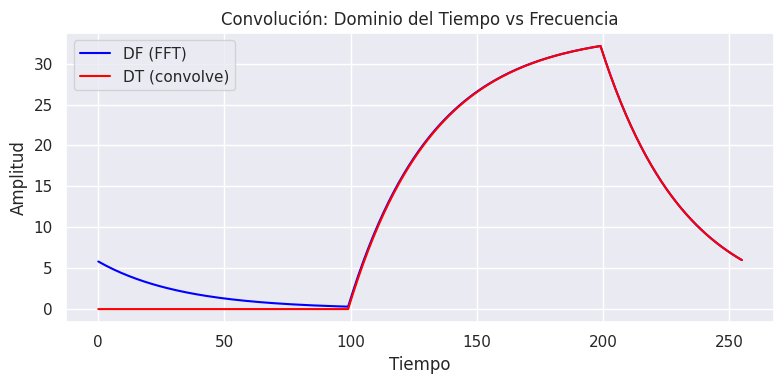

In [186]:
# Volver al dominio del tiempo (convolución vía frecuencia)
f3b = np.real(np.fft.ifft(fft_f3))

# Plot: comparación
plt.figure(figsize=(8, 4))
sns.lineplot(x=tiempo, y=f3b, label='DF (FFT)', color='blue')
sns.lineplot(x=tiempo, y=f3, label='DT (convolve)', color='red')
plt.title("Convolución: Dominio del Tiempo vs Frecuencia")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

---
# Correlación

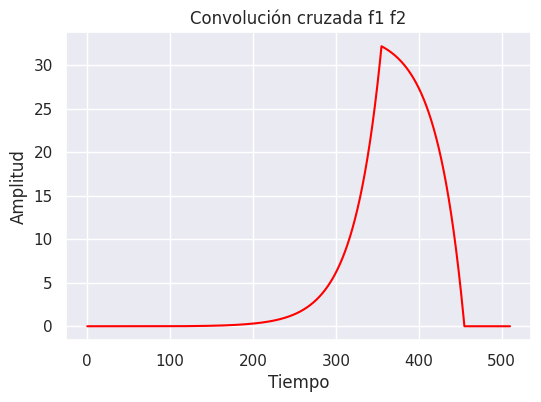

In [187]:
corr = correlate(f1, f2, mode="full")

plt.figure(figsize=(6, 4))
sns.lineplot(corr, color="red")
plt.title("Convolución cruzada f1 f2")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.show()

In [188]:
def cross_correlation_normalized(x, y):
    """
    Calcula la correlación cruzada normalizada entre dos señales x e y.

    Retorna:
        correlation: array con los valores de correlación cruzada normalizada
        lags: array con los valores de desplazamiento (lag)
    """
    N = len(x)
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    corr = correlate(x_centered, y_centered, mode='full')
    corr_normalized = corr / (np.std(x) * np.std(y) * N)
    lags = np.arange(-N + 1, N)

    return corr_normalized, lags

def plot_cross_correlation(corr, lags, f1_name, f2_name, xlim0 = -50, xlim1 = 50):
    # Gráfico de correlación cruzada (como ccf en R)
    plt.figure(figsize=(8, 5))
    plt.bar(lags, corr, width=1)
    plt.axhline(0, color='black')
    plt.axhline(2/np.sqrt(N), color='purple', linestyle='--')
    plt.axhline(-2/np.sqrt(N), color='purple', linestyle='--')
    plt.title(f'Correlación cruzada ({f1_name} vs {f2_name})')
    plt.xlabel('Lag')
    plt.ylabel('Correlación')
    plt.xlim(xlim0, xlim1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_signals(f1, f2 = None, f1_name = "", f2_name = ""):
    plt.figure(figsize=(8, 5))
    plt.plot(tiempo, f1, label=f1_name)
    if f2 is not None:
        plt.plot(tiempo, f2, label=f2_name, color='red')
        plt.title(f'Señales {f1_name} y {f2_name}')
    else:
        plt.title(f'Señal {f1_name}')
    plt.xlabel('Tiempo')
    plt.ylabel('Amplitud')
    plt.legend()

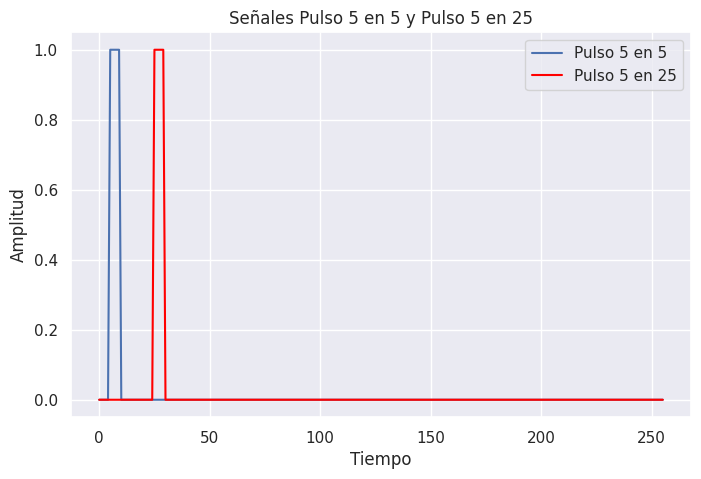

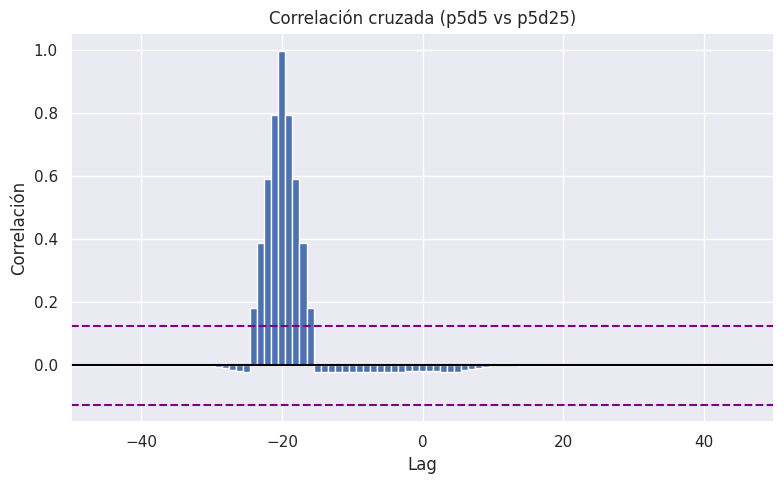

In [189]:
p5d5 = np.zeros(N)
p5d5[5:10] = 1

p5d25 = np.zeros(N)
p5d25[25:30] = 1

plot_signals(p5d5, p5d25, "Pulso 5 en 5", "Pulso 5 en 25")

correlation, lags = cross_correlation_normalized(p5d5, p5d25)

plot_cross_correlation(correlation, lags, 'p5d5', 'p5d25')

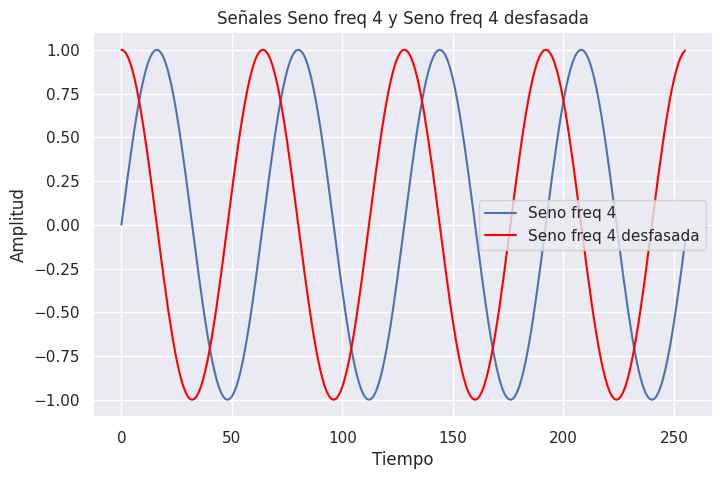

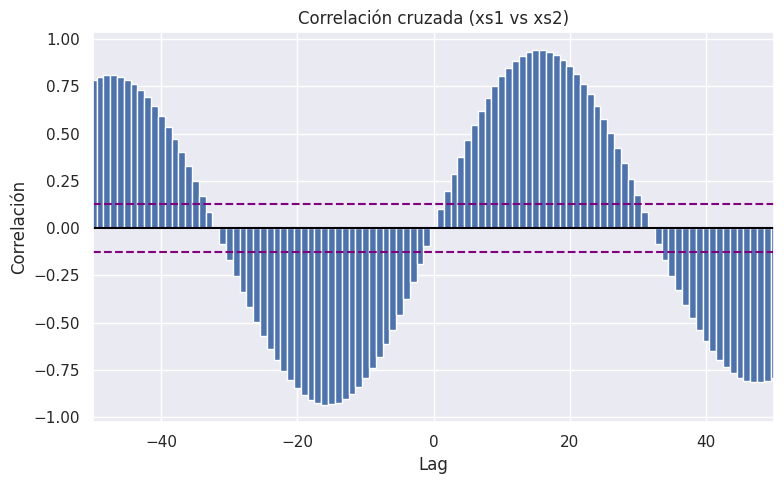

In [190]:
frecuencia = 4  # ciclos por N muestras

# Señales senoidales
xs1 = np.sin(2 * np.pi * frecuencia * tiempo / N)
xs2 = np.sin(2 * np.pi * frecuencia * tiempo / N + np.pi/2)  # desfase de π/2

plot_signals(xs1, xs2, "Seno freq 4", "Seno freq 4 desfasada")

# Correlación cruzada
correlation, lags = cross_correlation_normalized(xs1, xs2)

plot_cross_correlation(correlation, lags, 'xs1', 'xs2')

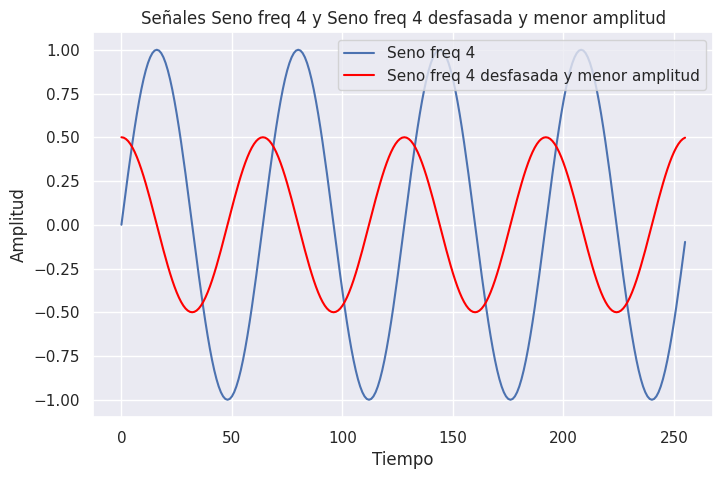

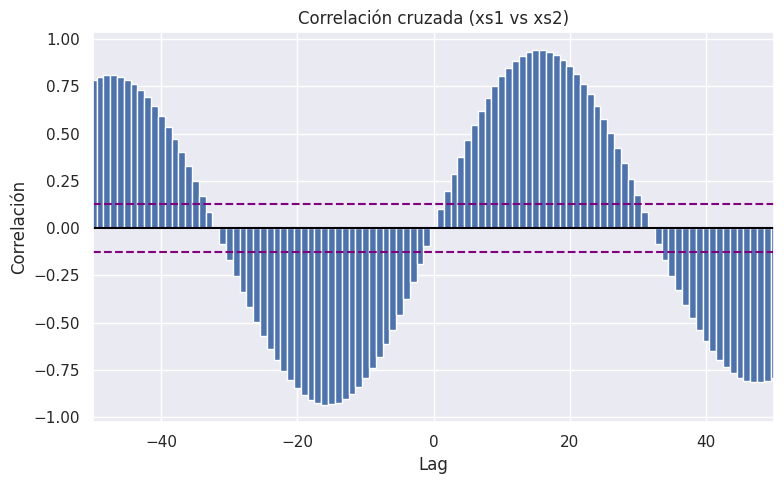

In [191]:
frecuencia = 4  # ciclos por N muestras

# Señales senoidales
xs1 = np.sin(2 * np.pi * frecuencia * tiempo / N)
xs2 = 0.5 * np.sin(2 * np.pi * frecuencia * tiempo / N + np.pi/2)  # desfase de π/2

plot_signals(xs1, xs2, "Seno freq 4", "Seno freq 4 desfasada y menor amplitud")

# Correlación cruzada
correlation, lags = cross_correlation_normalized(xs1, xs2)

plot_cross_correlation(correlation, lags, 'xs1', 'xs2')

Misma correlación cruzada gracias a la Normalización.

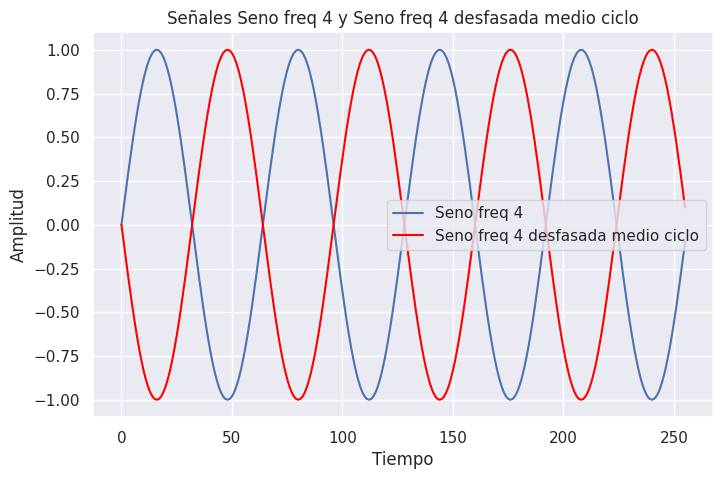

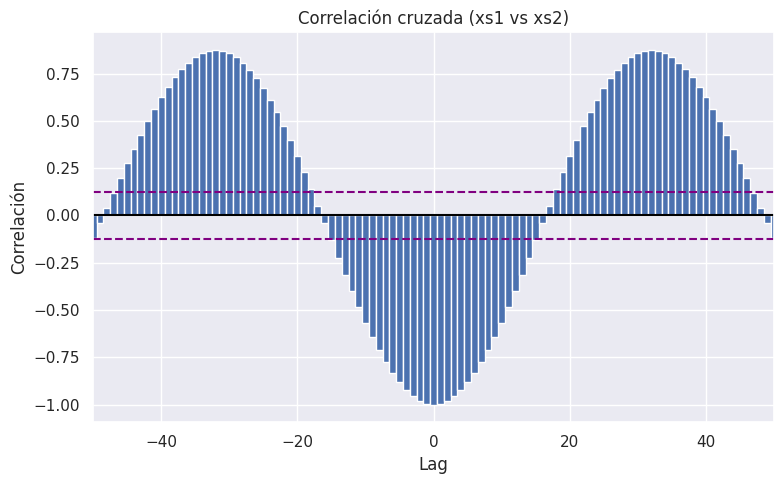

In [192]:
frecuencia = 4  # ciclos por N muestras

# Señales senoidales
xs1 = np.sin(2 * np.pi * frecuencia * tiempo / N)
xs2 = np.sin(2 * np.pi * frecuencia * tiempo / N + np.pi)  # desfase de π

plot_signals(xs1, xs2, "Seno freq 4", "Seno freq 4 desfasada medio ciclo")

# Correlación cruzada
correlation, lags = cross_correlation_normalized(xs1, xs2)

plot_cross_correlation(correlation, lags, 'xs1', 'xs2')

Se ve bien cómo, en lag 0, es decir, cuando no se desplaza ninguna función seno (gráfico original), la correlación es -1: cuando una sube, la otra baja.

## Autocorrelación

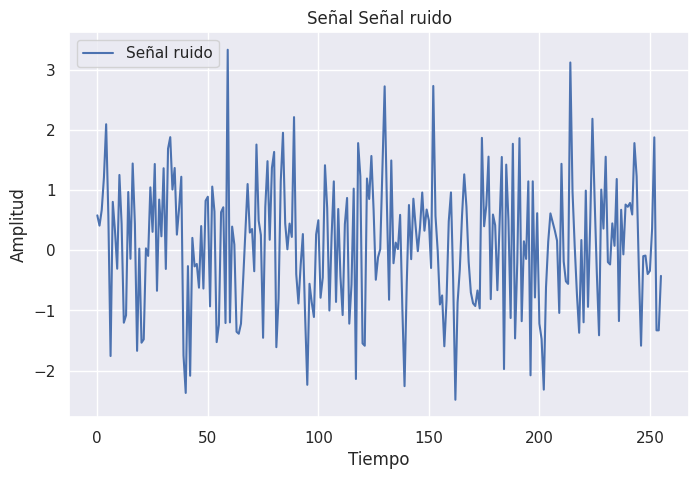

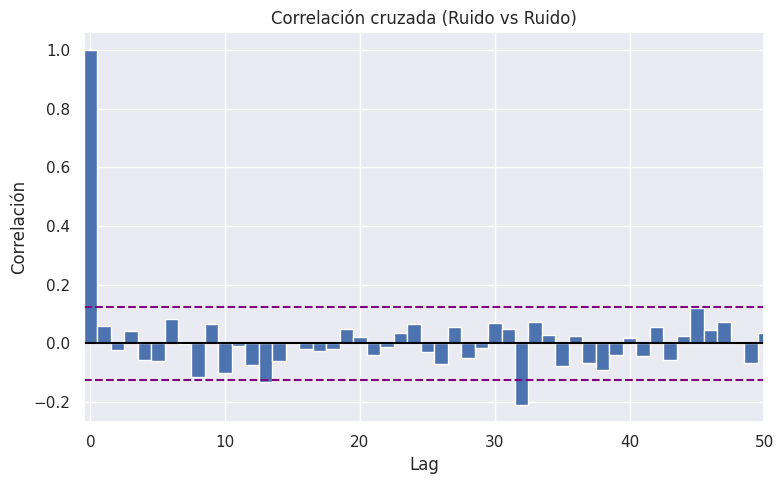

In [195]:
ruido = np.random.normal(size=N)
plot_signals(f1 = ruido, f1_name = "Señal ruido")

# Autocorrelacion
cross_correlation, lags = cross_correlation_normalized(ruido, ruido)

plot_cross_correlation(cross_correlation, lags, 'Ruido', 'Ruido', -0.5, 50)

La autocorrelación es solo alta cuando no se desplaza. Luego, no hay más alta o baja correlación. **Esta es una forma de ver si una señal es aleatoria**.

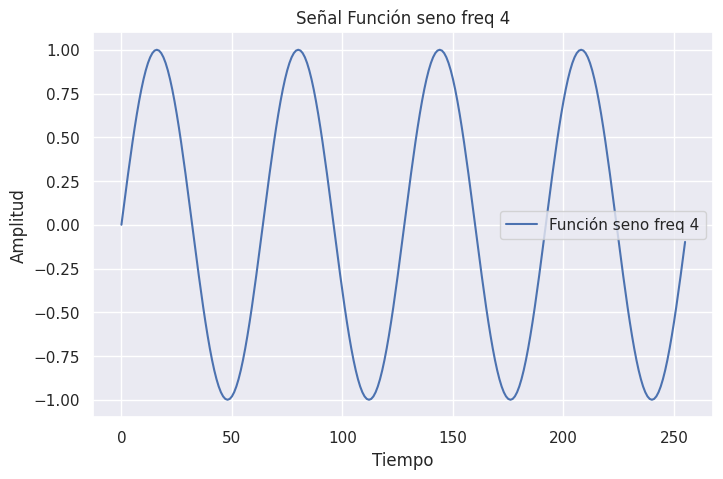

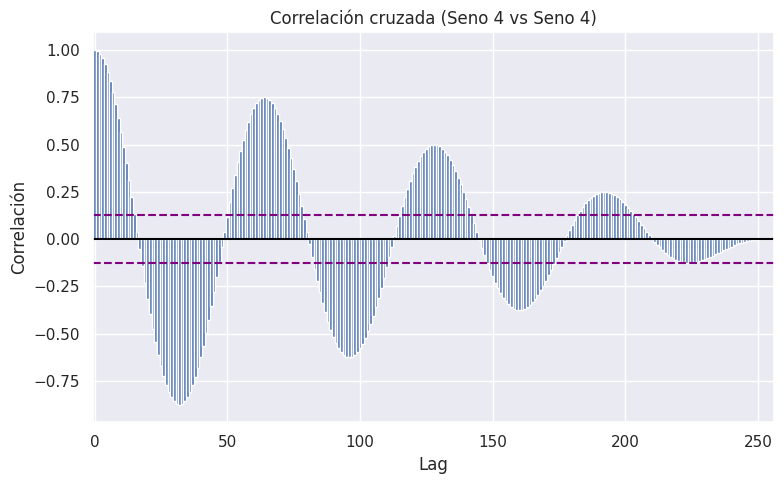

In [200]:
xs = np.sin(2 * np.pi * 4 * tiempo / N)

plot_signals(f1=xs, f1_name="Función seno freq 4")

# Autocorrelacion
cross_correlation, lags = cross_correlation_normalized(xs, xs)

plot_cross_correlation(cross_correlation, lags, 'Seno 4', 'Seno 4', -0.5, 256)

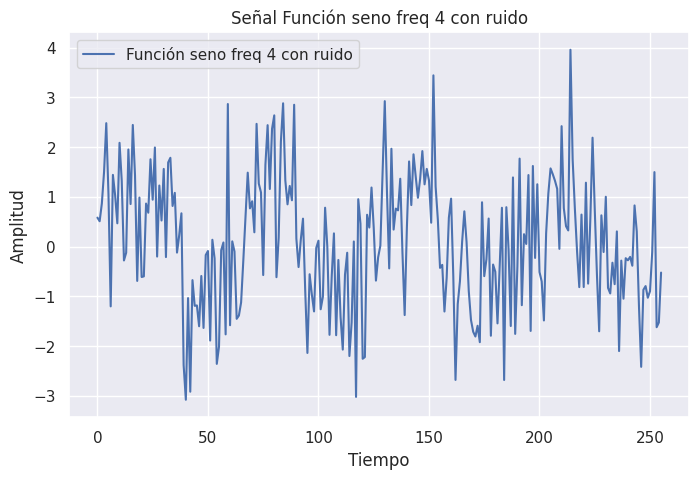

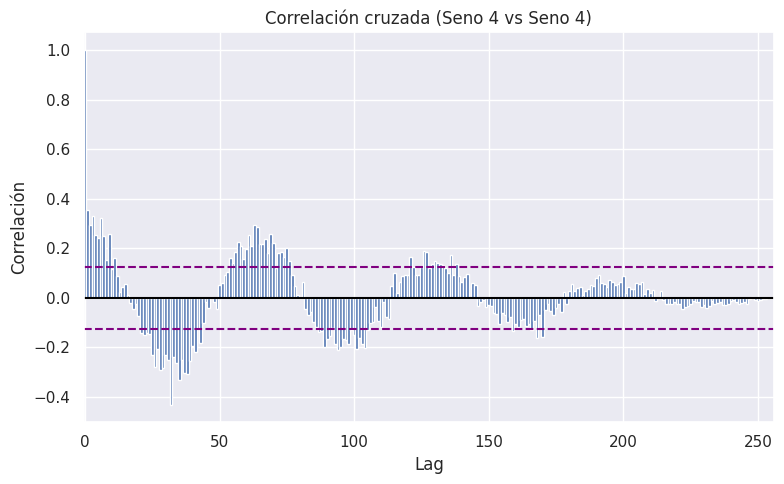

In [201]:
xsr = xs + ruido

plot_signals(f1=xsr, f1_name="Función seno freq 4 con ruido")

# Autocorrelacion
cross_correlation, lags = cross_correlation_normalized(xsr, xsr)

plot_cross_correlation(cross_correlation, lags, 'Seno 4', 'Seno 4', -0.5, 256)

Nuevamente, además de la componente cíclica, **nos permite ver la componente aleatoria**, agregada con el ruido.

### Ejercicio

In [296]:
np.random.seed(42)  # Para reproducibilidad

N = 256
tiempo = np.arange(0, N)

# Simular ventas para local 1 con algo de ruido
constante_a = 100
seno2_a = 50 * np.sin(2 * np.pi * 2 * tiempo / N)
seno10_a = 25 * np.sin(2 * np.pi * 10 * tiempo / N)
ventas_local_a = constante_a + seno2_a + seno10_a + np.random.normal(0, 20, size=tiempo.shape)

# Crear ventas para local 2 con un desfase y algo de ruido
desfase = 10
constante_b = 100
tiempo_desfasado = tiempo + desfase
seno2_b = 20 * np.sin(2 * np.pi * 2 * tiempo_desfasado / N)
seno10_b = 25 * np.sin(2 * np.pi * 10 * tiempo_desfasado / N)
ventas_local_b = constante_b + seno2_b + seno10_b + np.random.uniform(0, 50, size=tiempo.shape)


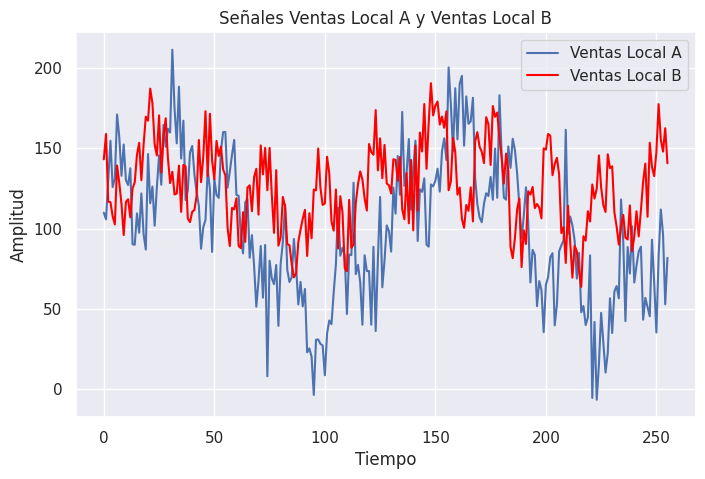

In [297]:
plot_signals(ventas_local_a, ventas_local_b, "Ventas Local A", "Ventas Local B")

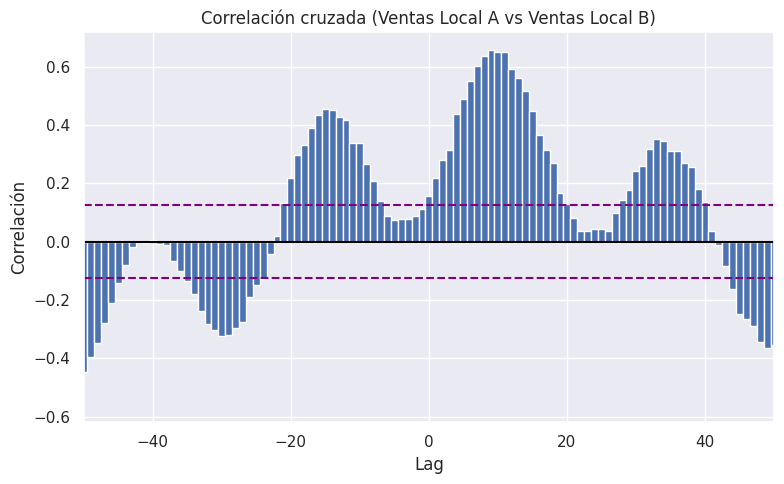

In [298]:
cross_corr, lags = cross_correlation_normalized(ventas_local_a, ventas_local_b)

plot_cross_correlation(cross_corr, lags, 'Ventas Local A', 'Ventas Local B')

Se puede ver cómo hay un **pico de mayor correlación en el desfase de +10**, **debido a cómo fueron contruidas ambas señales** (muy similares, aunque no a simple vista) y gracias al **desfase de 10 días agregado al Local B**.